# Módulo 7 - Introdução ao aprendizado de máquina

## 7.2 - Preparação dos dados (parte 1)

In [186]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [146]:
dados = pd.read_excel('../data/analise_dados_mod7.xlsx')

In [147]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [148]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [149]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)                                                    2762
Empreendedor ou Empregado (CNPJ)                                    410
Desempregado, buscando recolocação                                  350
Estagiário                                                          188
Servidor Público                                                    156
Trabalho na área Acadêmica/Pesquisador                               86
Somente Estudante (graduação)                                        82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil      69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil        46
Somente Estudante (pós-graduação)                                    44
Freelancer                                                           39
Prefiro não informar                                                 24
Desempregado e não estou buscando recolocação                        15
Name: count, dtype: int64

In [150]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?']=='Empregado (CLT)']

In [151]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)    2762
Name: count, dtype: int64

In [152]:
dados['COR/RACA/ETNIA'].value_counts()

COR/RACA/ETNIA
Branca                  1805
Parda                    661
Preta                    181
Amarela                   85
Prefiro não informar      16
Outra                     10
Indígena                   4
Name: count, dtype: int64

Irei retirar dados com pouca representatividade

In [153]:
lista_valores_retirar = ["Prefiro não informar", "Outra", "Indígena"]

In [154]:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_valores_retirar)]

Criarei coluna de classificação das  (0 se branco, 1 se outras)

In [155]:
dados['NÃO BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!= 'Branca' else 0)

In [156]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?
de 1 a 2 anos                             743
de 3 a 4 anos                             584
de 4 a 6 anos                             416
Menos de 1 ano                            353
Mais de 10 anos                           277
de 7 a 10 anos                            232
Não tenho experiência na área de dados    127
Name: count, dtype: int64

In [157]:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r"(\d+)")

In [158]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

TEMPO_EXPERIENCIA
1      1096
3       584
4       416
10      277
7       232
NaN     127
Name: count, dtype: int64

In [159]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [160]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

TEMPO_EXPERIENCIA
1     1096
3      584
4      416
10     277
7      232
0      127
Name: count, dtype: int64

In [161]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
Acima de 3.000      1313
de 101 a 500         503
de 1.001 a 3.000     368
de 501 a 1.000       248
de 51 a 100          146
de 11 a 50           112
de 6 a 10             24
de 1 a 5              18
Name: count, dtype: int64

In [162]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [163]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
Acima de 3000     1313
de 101 a 500       503
de 1001 a 3000     368
de 501 a 1000      248
de 51 a 100        146
de 11 a 50         112
de 6 a 10           24
de 1 a 5            18
Name: count, dtype: int64

In [164]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r"(\d+)")

In [165]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
3000    1313
101      503
1001     368
501      248
51       146
11       112
6         24
1         18
Name: count, dtype: int64

## 7.2 - Preparação dos dados (parte 2)

In [166]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts(dropna=False)

Qual o principal motivo da sua insatisfação com a empresa atual?
NaN                                                                                                                                                         2071
Gostaria de trabalhar em em outra área de atuação                                                                                                             69
Salário atual não corresponde ao mercado                                                                                                                      53
Falta de oportunidade de crescimento no emprego atual                                                                                                         46
Falta de maturidade analítica na empresa                                                                                                                      45
                                                                                                                                  

Vou criar coluna de insatisfação, classificando as insastifações com salário como 1

In [167]:
dados['INSATISFACAO'] = 0

In [168]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [169]:
dados['INSATISFACAO'].value_counts(dropna=False)

INSATISFACAO
0    2453
1     279
Name: count, dtype: int64

In [170]:
dados['NIVEL DE ENSINO'].value_counts()

NIVEL DE ENSINO
Graduação/Bacharelado         1024
Pós-graduação                  975
Mestrado                       306
Estudante de Graduação         271
Doutorado ou Phd               100
Não tenho graduação formal      52
Prefiro não informar             4
Name: count, dtype: int64

In [171]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else 
                               1 if x == 'Estudante de Graduação' else 
                               2 if x == 'Graduação/Bacharelado' else 
                               3 if x == 'Pós-graduação' else
                               4 if x == 'Mestrado' else
                               5 if x == 'Doutorado ou Phd' else -1)

In [172]:
dados['NIVEL DE ENSINO'].value_counts()

NIVEL DE ENSINO
 2    1024
 3     975
 4     306
 1     271
 5     100
 0      52
-1       4
Name: count, dtype: int64

## 7.2 - Preparação dos dados (parte 3)

In [173]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [174]:
dados = dados[['IDADE', 'SALARIO', 'GENERO', 'NÃO BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'REGIAO ONDE MORA', 'SETOR', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL']]

In [175]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

Divisão dos dados (Treino e Teste)

In [176]:
x = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

In [177]:
xtrain, xtest, ytrain, ytest =train_test_split(x, y, test_size=0.2, random_state=42)

Normalizando os dados

In [178]:
scaler = StandardScaler()

xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.fit_transform(xtest)

## 7.3 - Introdução a regressão linear (parte 1)

In [179]:
model = LinearRegression()

In [180]:
model.fit(xtrain_scaled, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](35,)","[-133.03,-423.4 ,2004.02,...,-256.25,-201.49,-576.23]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.013e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,35
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,35
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](35,)","[66.32,62.55,55.44,...,22.11,13.6 , 6.75]"


In [181]:
y_pred= model.predict(xtest_scaled)

Avaliando modelo

In [182]:
mse = mean_squared_error(ytest, y_pred)
mse

23048733.978297204

Valor muito alto, indica que o modelo não está com previsão precisa

In [183]:
mae = mean_absolute_error(ytest, y_pred)
mae

3298.9644642069393

In [184]:
r2 = r2_score(ytest, y_pred)
r2

0.5297347873934932

Vamos analisar os dados em conjunto. Com os resultados nós concluímos que para um modelo real de produção nosso modelo não seria aceitável. 

## 7.3 - Introdução a regressão linear (parte 2)

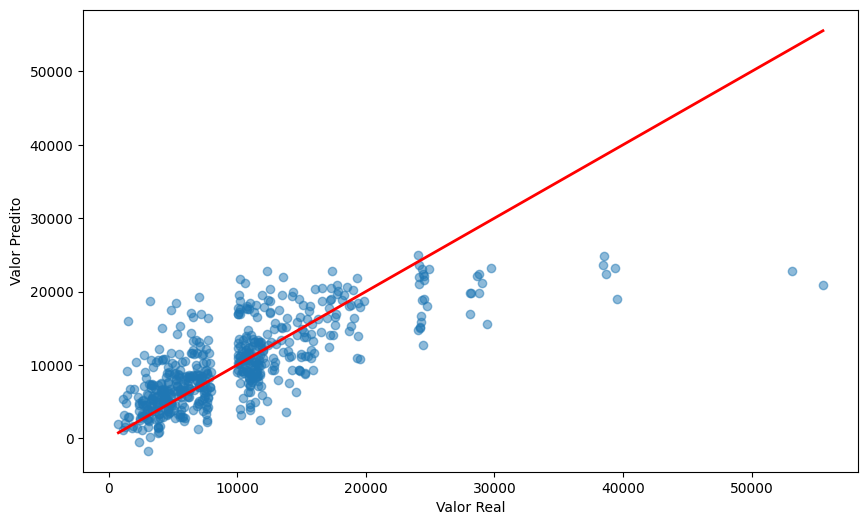

In [187]:
plt.figure(figsize=(10,6))

plt.scatter(ytest, y_pred, alpha=0.5)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")

plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linewidth=2)

plt.show()


In [189]:
nomes_atributos = xtrain.columns
nomes_atributos

Index(['IDADE', 'NÃO BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='str')

In [192]:
coefs = pd.DataFrame(model.coef_, columns=['coeficiente'], index= nomes_atributos)
coefs

,coeficiente
IDADE,-133.027283
NÃO BRANCA,-423.401696
TEMPO_EXPERIENCIA,2004.015472
INSATISFACAO,-535.533311
NIVEL DE ENSINO,843.824926
NUMERO DE FUNCIONARIOS,797.206111
GENERO_Masculino,555.450771
GENERO_Prefiro não informar,92.976498
SETOR_Educação,-157.506247
SETOR_Entretenimento ou Esportes,231.353518


In [195]:
coefs = coefs.sort_values(by='coeficiente', ascending=False)

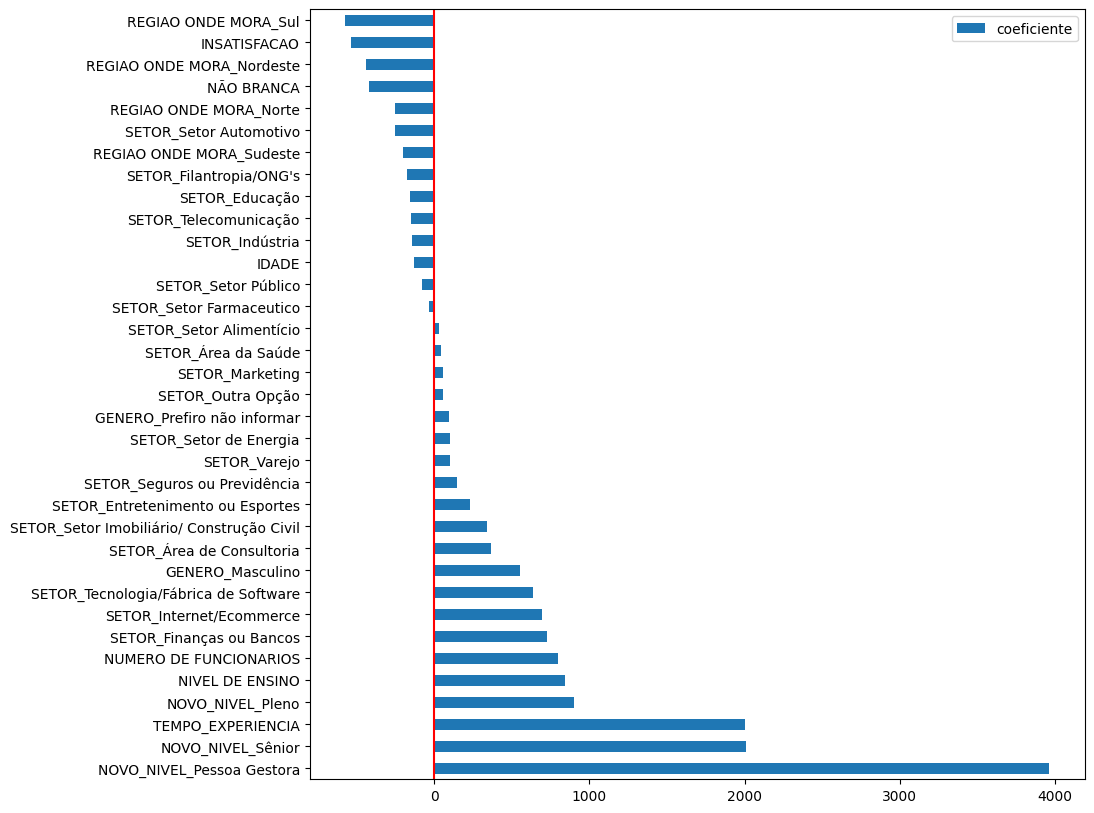

In [199]:
coefs.plot.barh(figsize=(10,10))
plt.axvline(x=0, color='red')